## MLP

In [3]:
import torch
import sys
import torch.nn as nn
import torch.optim as optim
sys.path.append("../")

from datasets.dataloader import get_wireless_dataloader

# Define Positional Encoding (Fixed for Batch Processing)
class PositionalEncoding(nn.Module):
    def __init__(self, num_freqs=10, input_dim=3):
        super(PositionalEncoding, self).__init__()
        self.num_freqs = num_freqs
        # Each input dimension is encoded as:
        # original value + sin(2^i * x) + cos(2^i * x) for i in 0,...,num_freqs-1
        # Hence, output_dim = input_dim * (1 + 2*num_freqs)
        self.output_dim = input_dim * (2 * num_freqs + 1)

    def forward(self, x):
        """Handles batched inputs (B, 3) correctly"""
        B, D = x.shape  # B: Batch size, D: Input dim (should be 3)
        freqs = 2 ** torch.arange(self.num_freqs, dtype=torch.float32, device=x.device)  # [num_freqs]
        # Compute scaled versions for sin and cos terms: shape becomes [B, 3, num_freqs]
        x_expanded = x.unsqueeze(-1) * freqs  
        # Include the original x only once per dimension: shape [B, 3, 1]
        x_original = x.unsqueeze(-1)
        # Concatenate the original, sine, and cosine terms along the last dimension.
        x_encoded = torch.cat([x_original, torch.sin(x_expanded), torch.cos(x_expanded)], dim=-1)
        return x_encoded.view(B, -1)  # Flatten the last two dimensions

# Define MLP Model
class MLPChannelEstimator(nn.Module):
    def __init__(self, input_dim=3, num_freqs=10, hidden_dim=128, tx_ant=16, rx_ant=2):
        super(MLPChannelEstimator, self).__init__()
        self.tx_ant = tx_ant
        self.rx_ant = rx_ant
        self.pos_encoding = PositionalEncoding(num_freqs=num_freqs, input_dim=input_dim)
        encoded_dim = self.pos_encoding.output_dim

        # MLP with skip connections
        self.fc1 = nn.Linear(encoded_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim + encoded_dim, hidden_dim)  # Skip connection
        self.fc5 = nn.Linear(hidden_dim, hidden_dim)
        self.fc6 = nn.Linear(hidden_dim, hidden_dim)
        self.fc7 = nn.Linear(hidden_dim, hidden_dim)
        self.fc8 = nn.Linear(hidden_dim, tx_ant * rx_ant * 2)  # Output for I, Q pairs

    def forward(self, x):
        """Now supports batch input (B, 3)"""
        x = self.pos_encoding(x)  # Apply positional encoding -> (B, encoded_dim)
        x1 = torch.relu(self.fc1(x))
        x2 = torch.relu(self.fc2(x1))
        x3 = torch.relu(self.fc3(x2))
        # Concatenate the original encoded input with the features from fc3 (skip connection)
        x4 = torch.cat([x, x3], dim=-1)
        x4 = torch.relu(self.fc4(x4))
        x5 = torch.relu(self.fc5(x4))
        x6 = torch.relu(self.fc6(x5))
        x7 = torch.relu(self.fc7(x6))
        x_out = self.fc8(x7)
        return x_out.view(x.shape[0], self.tx_ant, self.rx_ant, 2)  # Reshape to (B, tx_ant, rx_ant, 2)

# Load Dataset
dataloader = get_wireless_dataloader(
    "../datasets/outputs/conf_16x2_414u_5.0ghz_sbrRT_sc104.mat",
    batch_size=16,
    num_pc=16378,
    drop_last=True
)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model, Loss, Optimizer
# Note: Based on your dataset, there are 16 tx antennas and 2 rx antennas.
tx_ant, rx_ant = 16, 2
model = MLPChannelEstimator(tx_ant=tx_ant, rx_ant=rx_ant).to(device)
criterion = nn.MSELoss()  # Mean Squared Error for (I, Q) pairs
optimizer = optim.Adam(model.parameters(), lr=5e-4)

# Training Loop
num_epochs = 50  # Adjust as needed
for epoch in range(num_epochs):
    total_loss = 0.0
    for batch in dataloader:
        rx_positions = batch["rx_position"].to(device)  # [B, 3]
        channel_matrix = batch["channel_matrix"].to(device)  # [B, tx_ant, rx_ant, 2]
        
        # Forward pass (Pass full batch to model)
        predicted_channel = model(rx_positions)  # [B, 16, 2, 2]

        # Compute loss
        loss = criterion(predicted_channel, channel_matrix)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}")

# Save Model
torch.save(model.state_dict(), "mlp_channel_estimator.pth")
print("Training Complete. Model saved.")


Epoch [1/50], Loss: 0.001215
Epoch [2/50], Loss: 0.000066
Epoch [3/50], Loss: 0.000017
Epoch [4/50], Loss: 0.000010
Epoch [5/50], Loss: 0.000008
Epoch [6/50], Loss: 0.000007
Epoch [7/50], Loss: 0.000007
Epoch [8/50], Loss: 0.000006
Epoch [9/50], Loss: 0.000006
Epoch [10/50], Loss: 0.000005
Epoch [11/50], Loss: 0.000005
Epoch [12/50], Loss: 0.000005
Epoch [13/50], Loss: 0.000005
Epoch [14/50], Loss: 0.000005
Epoch [15/50], Loss: 0.000005
Epoch [16/50], Loss: 0.000005
Epoch [17/50], Loss: 0.000005
Epoch [18/50], Loss: 0.000004
Epoch [19/50], Loss: 0.000004
Epoch [20/50], Loss: 0.000004
Epoch [21/50], Loss: 0.000004
Epoch [22/50], Loss: 0.000004
Epoch [23/50], Loss: 0.000004
Epoch [24/50], Loss: 0.000004
Epoch [25/50], Loss: 0.000004
Epoch [26/50], Loss: 0.000004
Epoch [27/50], Loss: 0.000004
Epoch [28/50], Loss: 0.000004
Epoch [29/50], Loss: 0.000004
Epoch [30/50], Loss: 0.000003
Epoch [31/50], Loss: 0.000003
Epoch [32/50], Loss: 0.000003
Epoch [33/50], Loss: 0.000003
Epoch [34/50], Loss

In [1]:
import torch
import sys
import torch.nn as nn
import torch.optim as optim
sys.path.append("../")
from datasets.dataloader import get_wireless_dataloader

# Define Positional Encoding (Fixed for Batch Processing)
class PositionalEncoding(nn.Module):
    def __init__(self, num_freqs=10, input_dim=3):
        super(PositionalEncoding, self).__init__()
        self.num_freqs = num_freqs
        # Output dimension: original value + sin and cos for each frequency.
        self.output_dim = input_dim * (2 * num_freqs + 1)

    def forward(self, x):
        """Handles batched inputs (B, 3) correctly"""
        B, D = x.shape  # B: Batch size, D: Input dimension (should be 3)
        freqs = 2 ** torch.arange(self.num_freqs, dtype=torch.float32, device=x.device)
        x_expanded = x.unsqueeze(-1) * freqs  # [B, 3, num_freqs]
        x_original = x.unsqueeze(-1)          # [B, 3, 1]
        x_encoded = torch.cat([x_original, torch.sin(x_expanded), torch.cos(x_expanded)], dim=-1)
        return x_encoded.view(B, -1)  # Flatten last two dimensions

# Define MLP Model
class MLPChannelEstimator(nn.Module):
    def __init__(self, input_dim=3, num_freqs=10, hidden_dim=128, tx_ant=16, rx_ant=2):
        super(MLPChannelEstimator, self).__init__()
        self.tx_ant = tx_ant
        self.rx_ant = rx_ant
        self.pos_encoding = PositionalEncoding(num_freqs=num_freqs, input_dim=input_dim)
        encoded_dim = self.pos_encoding.output_dim

        # MLP with skip connections
        self.fc1 = nn.Linear(encoded_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim + encoded_dim, hidden_dim)  # Skip connection
        self.fc5 = nn.Linear(hidden_dim, hidden_dim)
        self.fc6 = nn.Linear(hidden_dim, hidden_dim)
        self.fc7 = nn.Linear(hidden_dim, hidden_dim)
        self.fc8 = nn.Linear(hidden_dim, tx_ant * rx_ant * 2)  # Output for I, Q pairs

    def forward(self, x):
        """Expects batch input (B, 3) and outputs (B, tx_ant, rx_ant, 2)"""
        x = self.pos_encoding(x)
        x1 = torch.relu(self.fc1(x))
        x2 = torch.relu(self.fc2(x1))
        x3 = torch.relu(self.fc3(x2))
        x4 = torch.cat([x, x3], dim=-1)  # Skip connection
        x4 = torch.relu(self.fc4(x4))
        x5 = torch.relu(self.fc5(x4))
        x6 = torch.relu(self.fc6(x5))
        x7 = torch.relu(self.fc7(x6))
        x_out = self.fc8(x7)
        return x_out.view(x.shape[0], self.tx_ant, self.rx_ant, 2)

# Load Dataset
dataloader = get_wireless_dataloader(
    "../datasets/outputs/conf_16x2_414u_5.0ghz_sbrRT_sc104.mat",
    batch_size=16,
    num_pc=16378,
    drop_last=True
)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model, Loss, Optimizer
tx_ant, rx_ant = 16, 2  # 16 transmit antennas, 2 receive antennas
model = MLPChannelEstimator(tx_ant=tx_ant, rx_ant=rx_ant).to(device)
criterion = nn.MSELoss()  # Mean Squared Error for (I, Q) pairs
optimizer = optim.Adam(model.parameters(), lr=5e-4)

# Training Loop with Diagnostics
num_epochs = 50  # Adjust as needed
for epoch in range(num_epochs):
    total_loss = 0.0
    print(f"Epoch {epoch+1}/{num_epochs}")
    for batch_idx, batch in enumerate(dataloader):
        rx_positions = batch["rx_position"].to(device)           # Shape: [B, 3]
        channel_matrix = batch["channel_matrix"].to(device)        # Shape: [B, tx_ant, rx_ant, 2]
        
        # Forward pass: one prediction per receiver in the batch
        predicted_channel = model(rx_positions)                    # Expected shape: [B, tx_ant, rx_ant, 2]
        
        # Diagnostic: Print shapes for this batch
        print(f"  Batch {batch_idx}:")
        print(f"    rx_positions shape: {rx_positions.shape}")
        print(f"    Predicted channel shape: {predicted_channel.shape}")
        print(f"    Ground truth channel shape: {channel_matrix.shape}")
        
        # Iterate over each receiver (batch element)
        for i in range(rx_positions.shape[0]):
            pred_mat = predicted_channel[i]  # Shape: [tx_ant, rx_ant, 2]
            gt_mat = channel_matrix[i]         # Shape: [tx_ant, rx_ant, 2]
            # Check that the predicted and ground truth matrices cover all transmitter-receiver points
            print(f"      Receiver {i}: Predicted CSI shape: {pred_mat.shape}, Ground truth CSI shape: {gt_mat.shape}")
        
        # Compute loss and optimize
        loss = criterion(predicted_channel, channel_matrix)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / (batch_idx + 1)
    print(f"  Average Loss: {avg_loss:.6f}\n")

# Save Model after training
torch.save(model.state_dict(), "mlp_channel_estimator.pth")
print("Training Complete. Model saved.")


KeyError: 'path_loss'

## Inference

Batch 0:
Ground Truth Real: (16, 16, 2)
Ground Truth Imaginary: (16, 16, 2)
Predicted Real: (16, 16, 2)
Predicted Imaginary: (16, 16, 2)
Batch 0:
Real range: [-0.00318, 0.00343]
Imag range: [-0.00346, 0.00166]
----------------------------------------
Batch 1:
Ground Truth Real: (16, 16, 2)
Ground Truth Imaginary: (16, 16, 2)
Predicted Real: (16, 16, 2)
Predicted Imaginary: (16, 16, 2)
Batch 1:
Real range: [-0.00346, 0.00342]
Imag range: [-0.00306, 0.00443]
----------------------------------------
Batch 2:
Ground Truth Real: (16, 16, 2)
Ground Truth Imaginary: (16, 16, 2)
Predicted Real: (16, 16, 2)
Predicted Imaginary: (16, 16, 2)
Batch 2:
Real range: [-0.00313, 0.00316]
Imag range: [-0.00274, 0.00332]
----------------------------------------
Batch 3:
Ground Truth Real: (16, 16, 2)
Ground Truth Imaginary: (16, 16, 2)
Predicted Real: (16, 16, 2)
Predicted Imaginary: (16, 16, 2)
Batch 3:
Real range: [-0.00345, 0.00284]
Imag range: [-0.00455, 0.00510]
-------------------------------------

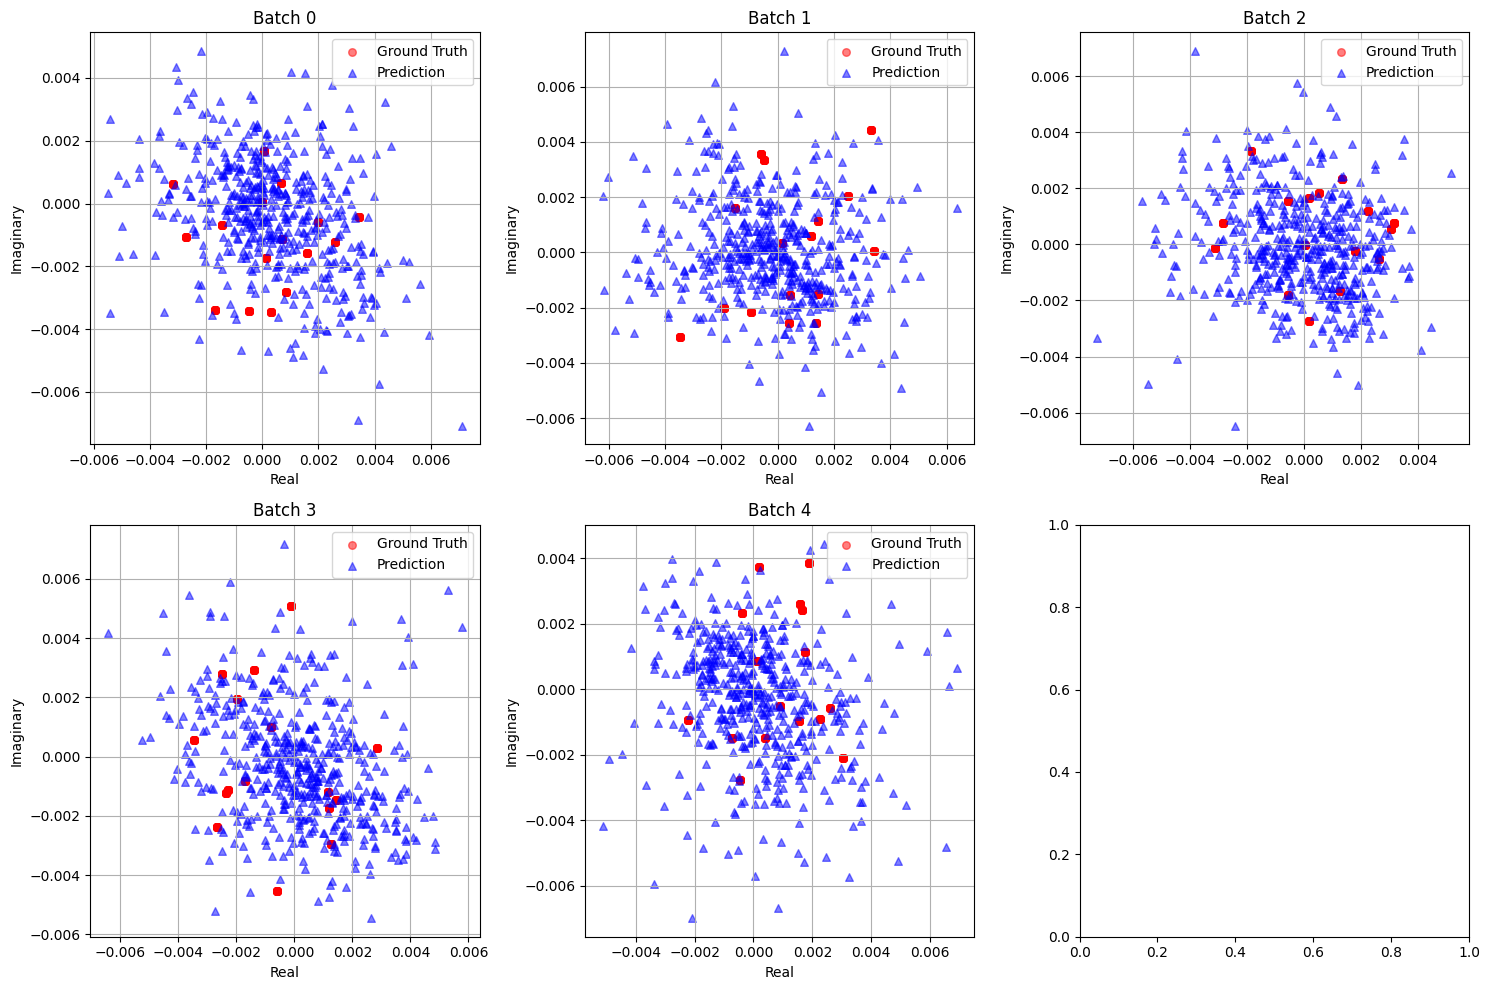

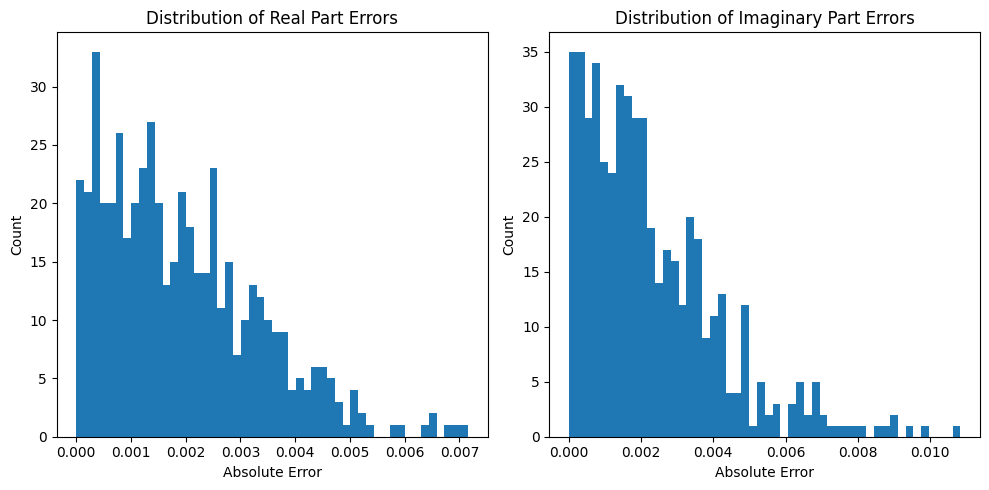

In [14]:
import torch
import matplotlib.pyplot as plt
import sys
import torch.nn as nn

sys.path.append("../")
from datasets.dataloader import get_wireless_dataloader

# [Previous PositionalEncoding and MLPChannelEstimator classes remain the same]
class PositionalEncoding(nn.Module):
    def __init__(self, num_freqs=10, input_dim=3):
        super(PositionalEncoding, self).__init__()
        self.num_freqs = num_freqs
        self.output_dim = input_dim * (2 * num_freqs + 1)

    def forward(self, x):
        B, D = x.shape
        freqs = 2 ** torch.arange(self.num_freqs, dtype=torch.float32, device=x.device)
        x_expanded = x.unsqueeze(-1) * freqs
        x_original = x.unsqueeze(-1)
        x_encoded = torch.cat([x_original, torch.sin(x_expanded), torch.cos(x_expanded)], dim=-1)
        return x_encoded.view(B, -1)

class MLPChannelEstimator(nn.Module):
    def __init__(self, input_dim=3, num_freqs=10, hidden_dim=128, tx_ant=16, rx_ant=2):
        super(MLPChannelEstimator, self).__init__()
        self.tx_ant = tx_ant
        self.rx_ant = rx_ant
        self.pos_encoding = PositionalEncoding(num_freqs=num_freqs, input_dim=input_dim)
        encoded_dim = self.pos_encoding.output_dim

        self.fc1 = nn.Linear(encoded_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim + encoded_dim, hidden_dim)
        self.fc5 = nn.Linear(hidden_dim, hidden_dim)
        self.fc6 = nn.Linear(hidden_dim, hidden_dim)
        self.fc7 = nn.Linear(hidden_dim, hidden_dim)
        self.fc8 = nn.Linear(hidden_dim, tx_ant * rx_ant * 2)

    def forward(self, x):
        x = self.pos_encoding(x)
        x1 = torch.relu(self.fc1(x))
        x2 = torch.relu(self.fc2(x1))
        x3 = torch.relu(self.fc3(x2))
        x4 = torch.cat([x, x3], dim=-1)
        x4 = torch.relu(self.fc4(x4))
        x5 = torch.relu(self.fc5(x4))
        x6 = torch.relu(self.fc6(x5))
        x7 = torch.relu(self.fc7(x6))
        x_out = self.fc8(x7)
        return x_out.view(x.shape[0], self.tx_ant, self.rx_ant, 2)

# Load test dataset
test_dataloader = get_wireless_dataloader(
    "../datasets/outputs/conf_16x2_414u_5.0ghz_sbrRT_sc104.mat",
    batch_size=16,
    num_pc=16378,
    drop_last=True,
    train=False
)

# Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLPChannelEstimator(tx_ant=16, rx_ant=2).to(device)
model.load_state_dict(torch.load("mlp_channel_estimator.pth", map_location=device))
model.eval()

# Create a figure with subplots for multiple batches
num_batches_to_plot = 6
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.ravel()

# Process multiple batches
for batch_idx, batch in enumerate(test_dataloader):
    if batch_idx >= num_batches_to_plot:
        break
        
    rx_positions = batch["rx_position"].to(device)
    channel_matrix = batch["channel_matrix"].to(device)
    
    with torch.no_grad():
        predicted_channel = model(rx_positions)
    
    # Extract real and imaginary parts
    gt_real = channel_matrix[..., 0].cpu().numpy()
    gt_imag = channel_matrix[..., 1].cpu().numpy()
    pred_real = predicted_channel[..., 0].cpu().numpy()
    pred_imag = predicted_channel[..., 1].cpu().numpy()
    
    #print shape of real and imaginagry for both ground truth and predicted
    print(f"Batch {batch_idx}:")
    print(f"Ground Truth Real: {gt_real.shape}")
    print(f"Ground Truth Imaginary: {gt_imag.shape}")
    print(f"Predicted Real: {pred_real.shape}")
    print(f"Predicted Imaginary: {pred_imag.shape}")
    # Print ranges for this batch
    print(f"Batch {batch_idx}:")
    print(f"Real range: [{gt_real.min():.5f}, {gt_real.max():.5f}]")
    print(f"Imag range: [{gt_imag.min():.5f}, {gt_imag.max():.5f}]")
    print("-" * 40)
    
    # Flatten arrays for scatter plot
    gt_r = gt_real.flatten()
    gt_i = gt_imag.flatten()
    pr_r = pred_real.flatten()
    pr_i = pred_imag.flatten()
    
    # Create subplot
    ax = axs[batch_idx]
    ax.scatter(gt_r, gt_i, color='red', marker='o', label='Ground Truth', alpha=0.5, s=30)
    ax.scatter(pr_r, pr_i, color='blue', marker='^', label='Prediction', alpha=0.5, s=30)
    ax.set_xlabel("Real")
    ax.set_ylabel("Imaginary")
    ax.set_title(f"Batch {batch_idx}")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

# Optional: Create additional plot showing distribution of errors
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
errors_real = np.abs(gt_real - pred_real).flatten()
plt.hist(errors_real, bins=50)
plt.title("Distribution of Real Part Errors")
plt.xlabel("Absolute Error")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
errors_imag = np.abs(gt_imag - pred_imag).flatten()
plt.hist(errors_imag, bins=50)
plt.title("Distribution of Imaginary Part Errors")
plt.xlabel("Absolute Error")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

Number of ground truth points: 32
Number of predicted points: 32

Ground Truth unique values:
Unique real values: 1
Unique imag values: 1


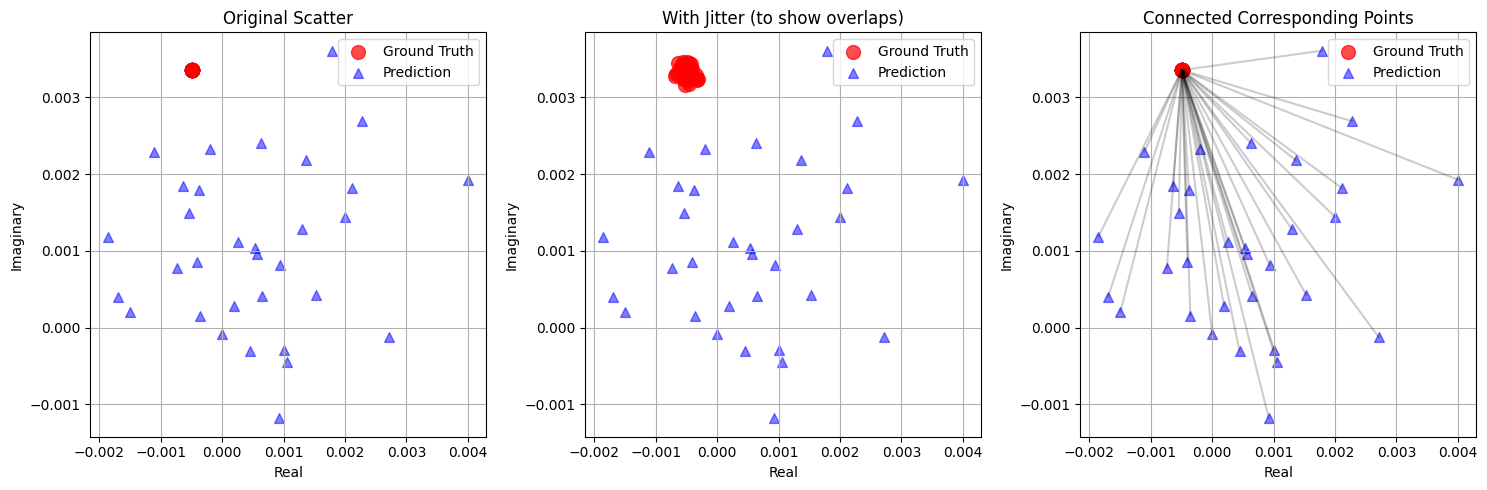


Example ground truth values (first 10 points):
Point 0: Real=-0.000492, Imag=0.003353
Point 1: Real=-0.000492, Imag=0.003353
Point 2: Real=-0.000492, Imag=0.003353
Point 3: Real=-0.000492, Imag=0.003353
Point 4: Real=-0.000492, Imag=0.003353
Point 5: Real=-0.000492, Imag=0.003353
Point 6: Real=-0.000492, Imag=0.003353
Point 7: Real=-0.000492, Imag=0.003353
Point 8: Real=-0.000492, Imag=0.003353
Point 9: Real=-0.000492, Imag=0.003353


In [15]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Load one batch
batch = next(iter(test_dataloader))
rx_positions = batch["rx_position"].to(device)
channel_matrix = batch["channel_matrix"].to(device)

with torch.no_grad():
    predicted_channel = model(rx_positions)

# Take one sample
sample_idx = 0

# Get ground truth and predictions
gt = channel_matrix[sample_idx].cpu().numpy()  # Shape: [16, 2, 2]
pred = predicted_channel[sample_idx].cpu().numpy()  # Shape: [16, 2, 2]

# Flatten the points
gt_real = gt[..., 0].flatten()
gt_imag = gt[..., 1].flatten()
pred_real = pred[..., 0].flatten()
pred_imag = pred[..., 1].flatten()

# Print point counts
print(f"Number of ground truth points: {len(gt_real)}")
print(f"Number of predicted points: {len(pred_real)}")

# Print some statistics
print("\nGround Truth unique values:")
print(f"Unique real values: {len(np.unique(gt_real))}")
print(f"Unique imag values: {len(np.unique(gt_imag))}")

# Create figure
plt.figure(figsize=(15, 5))

# Plot 1: Original scatter
plt.subplot(1, 3, 1)
plt.scatter(gt_real, gt_imag, color='red', marker='o', label='Ground Truth', alpha=0.7, s=100)
plt.scatter(pred_real, pred_imag, color='blue', marker='^', label='Prediction', alpha=0.5, s=50)
plt.title("Original Scatter")
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.grid(True)
plt.legend()

# Plot 2: With slight jitter to show overlapping points
plt.subplot(1, 3, 2)
jitter = 0.0001  # Small amount of random noise
plt.scatter(gt_real + np.random.randn(*gt_real.shape)*jitter, 
           gt_imag + np.random.randn(*gt_imag.shape)*jitter, 
           color='red', marker='o', label='Ground Truth', alpha=0.7, s=100)
plt.scatter(pred_real, pred_imag, color='blue', marker='^', label='Prediction', alpha=0.5, s=50)
plt.title("With Jitter (to show overlaps)")
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.grid(True)
plt.legend()

# Plot 3: Sequential lines connecting corresponding points
plt.subplot(1, 3, 3)
for i in range(len(gt_real)):
    plt.plot([gt_real[i], pred_real[i]], [gt_imag[i], pred_imag[i]], 'k-', alpha=0.2)
plt.scatter(gt_real, gt_imag, color='red', marker='o', label='Ground Truth', alpha=0.7, s=100)
plt.scatter(pred_real, pred_imag, color='blue', marker='^', label='Prediction', alpha=0.5, s=50)
plt.title("Connected Corresponding Points")
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Print some example values to show clustering
print("\nExample ground truth values (first 10 points):")
for i in range(10):
    print(f"Point {i}: Real={gt_real[i]:.6f}, Imag={gt_imag[i]:.6f}")

In [16]:
import torch
import numpy as np
import sys

sys.path.append("../")
from datasets.dataloader import get_wireless_dataloader

if __name__ == "__main__":
    # 1) Create the test dataloader (train=False)
    dataloader = get_wireless_dataloader(
        data_path="../datasets/outputs/conf_16x2_414u_5.0ghz_sbrRT_sc104.mat",
        batch_size=16,
        num_pc=16378,
        drop_last=False,
        train=False  # <-- Use the test set
    )

    # 2) Loop over all batches
    for batch_idx, batch in enumerate(dataloader):
        channel_matrix = batch["channel_matrix"]  # shape: [B, tx_ant, rx_ant, 2]

        # Extract real and imaginary parts: [B, tx_ant, rx_ant]
        real_part = channel_matrix[..., 0]
        imag_part = channel_matrix[..., 1]

        # Flatten each batch to see all antenna pairs at once
        real_flat = real_part.view(-1).numpy()
        imag_flat = imag_part.view(-1).numpy()

        # Check min, max, mean to see variation
        real_min, real_max = real_flat.min(), real_flat.max()
        imag_min, imag_max = imag_flat.min(), imag_flat.max()

        # Print summary for each batch
        print(f"Batch {batch_idx}:")
        print(f"  Real range: [{real_min:.5f}, {real_max:.5f}]")
        print(f"  Imag range: [{imag_min:.5f}, {imag_max:.5f}]")

        # If all real values are identical, min == max
        if np.isclose(real_min, real_max):
            print("  ** Real part is constant across this batch **")

        if np.isclose(imag_min, imag_max):
            print("  ** Imag part is constant across this batch **")

        print("-" * 40)


Batch 0:
  Real range: [-0.00272, 0.00343]
  Imag range: [-0.00346, 0.00386]
----------------------------------------
Batch 1:
  Real range: [-0.00345, 0.00342]
  Imag range: [-0.00222, 0.00510]
----------------------------------------
Batch 2:
  Real range: [-0.00285, 0.00333]
  Imag range: [-0.00282, 0.00443]
----------------------------------------
Batch 3:
  Real range: [-0.00346, 0.00316]
  Imag range: [-0.00306, 0.00294]
----------------------------------------
Batch 4:
  Real range: [-0.00251, 0.00226]
  Imag range: [-0.00455, 0.00355]
----------------------------------------
Batch 5:
  Real range: [-0.00167, 0.00143]
  Imag range: [-0.00339, -0.00152]
----------------------------------------
